In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
# Đọc file Excel
df = pd.read_excel("CPI-Vietnam.xls", sheet_name='Data', skiprows=3)
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='object')

In [6]:
df_vn = df[df['Country Name']=='Viet Nam']
df_vn.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
257,Viet Nam,VNM,Consumer price index (2010 = 100),FP.CPI.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,144.55037,148.407333,153.631652,159.069641,163.516948,168.783721,171.880423,177.305841,183.07341,189.702668


In [7]:
df_vn[["Country Name", "Country Code", "Indicator Name", "2010", "2011", "2012", "2013", "2015", "2016","2017","2018","2019","2020","2021","2022","2023","2024"]]

,Country Name,Country Code,Indicator Name,2010,2011,2012,2013,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
257,Viet Nam,VNM,Consumer price index (2010 = 100),100.0,118.677732,129.47112,138.00673,144.55037,148.407333,153.631652,159.069641,163.516948,168.783721,171.880423,177.305841,183.07341,189.702668


In [30]:
df_data = df[["Country Name", "Country Code", "Indicator Name", "2010", "2011", "2012", "2013", "2015", "2016","2017","2018","2019","2020","2021","2022","2023","2024"]].copy()
df_data.tail(10)


,Country Name,Country Code,Indicator Name,2010,2011,2012,2013,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
256,Virgin Islands (U.S.),VIR,Consumer price index (2010 = 100),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
257,Viet Nam,VNM,Consumer price index (2010 = 100),100.0,118.677732,129.471120,138.006730,144.550370,148.407333,153.631652,159.069641,163.516948,168.783721,171.880423,177.305841,183.073410,189.702668
258,Vanuatu,VUT,Consumer price index (2010 = 100),100.0,100.873793,102.232970,103.724482,107.149433,108.051706,111.384589,113.980923,117.129669,123.371920,126.262874,134.696358,149.758780,NaN
259,World,WLD,Consumer price index (2010 = 100),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
260,Samoa,WSM,Consumer price index (2010 = 100),100.0,105.235416,107.391709,108.046891,108.386922,109.801066,111.722472,116.411976,117.555522,115.711179,119.336647,132.418190,142.907891,146.012501
261,Kosovo,XKX,Consumer price index (2010 = 100),100.0,107.336418,109.994859,111.938825,111.815385,112.120830,113.789451,114.988562,118.065646,118.299686,122.267092,136.426245,143.171601,145.490194
262,"Yemen, Rep.",YEM,Consumer price index (2010 = 100),100.0,119.543562,131.360906,145.769151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Consumer price index (2010 = 100),100.0,105.000853,111.025772,117.443250,130.278204,138.880355,146.082949,152.671104,158.934972,164.072367,171.650452,183.734426,194.896740,203.396484
264,Zambia,ZMB,Consumer price index (2010 = 100),100.0,106.429397,113.428087,121.342732,144.042061,169.781989,180.949079,194.510438,212.308759,245.711424,299.818966,332.778677,369.000077,NaN
265,Zimbabwe,ZWE,Consumer price index (2010 = 100),100.0,103.466130,107.320581,109.075219,106.213145,104.573565,105.508414,116.712211,414.684309,2725.312815,5411.002445,11076.601788,NaN,NaN


In [8]:
! pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 3.0/3.0 MB 25.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 17.6 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.18.1-py3-none-any.whl size=139099 sha256=0b75dfbec00bcfcaf311a08713d9cad1c4e4d67fee2c11767ad98e5af5234d80
  Stored in directory: c:\users\buuhq\appdata\local\pip\cache\wheels\1a\57\6a\bb71346381d0d911cd4ce3026f1fa720da76707e4f01cf27dd
Successfully bu

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import yfinance as yf
import pandas as pd
meta = yf.Ticker("VNM")
data = meta.history(period="20y")
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2009-08-14 00:00:00-04:00,20.685430,20.708432,19.673393,19.949404,0,0.0,0.0,0.0
2009-08-17 00:00:00-04:00,19.972403,22.594500,19.320714,19.343714,0,0.0,0.0,0.0
2009-08-18 00:00:00-04:00,20.693101,20.693101,19.566060,19.742399,0,0.0,0.0,0.0
2009-08-19 00:00:00-04:00,19.803731,20.118076,19.604390,20.033739,0,0.0,0.0,0.0
2009-08-20 00:00:00-04:00,20.248414,20.953774,20.240747,20.677763,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2025-05-05 00:00:00-04:00,12.240000,12.290000,12.220000,12.270000,208300,0.0,0.0,0.0
2025-05-06 00:00:00-04:00,12.230000,12.300000,12.200000,12.220000,579200,0.0,0.0,0.0
2025-05-07 00:00:00-04:00,12.260000,12.420000,12.260000,12.420000,362400,0.0,0.0,0.0


In [4]:
data.to_csv('VML.csv')

In [5]:
df = pd.read_csv('VML.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2009-08-14 00:00:00-04:00,20.685430,20.708432,19.673393,19.949404,0,0.0,0.0,0.0
1,2009-08-17 00:00:00-04:00,19.972403,22.594500,19.320714,19.343714,0,0.0,0.0,0.0
2,2009-08-18 00:00:00-04:00,20.693101,20.693101,19.566060,19.742399,0,0.0,0.0,0.0
3,2009-08-19 00:00:00-04:00,19.803731,20.118076,19.604390,20.033739,0,0.0,0.0,0.0
4,2009-08-20 00:00:00-04:00,20.248414,20.953774,20.240747,20.677763,0,0.0,0.0,0.0


In [16]:
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.strftime('%Y-%m-%d')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2009-08-14,20.685430,20.708432,19.673393,19.949404,0,0.0,0.0,0.0
1,2009-08-17,19.972403,22.594500,19.320714,19.343714,0,0.0,0.0,0.0
2,2009-08-18,20.693101,20.693101,19.566060,19.742399,0,0.0,0.0,0.0
3,2009-08-19,19.803731,20.118076,19.604390,20.033739,0,0.0,0.0,0.0
4,2009-08-20,20.248414,20.953774,20.240747,20.677763,0,0.0,0.0,0.0


In [18]:
df = df.set_index(keys='Date')

<Axes: xlabel='Date'>

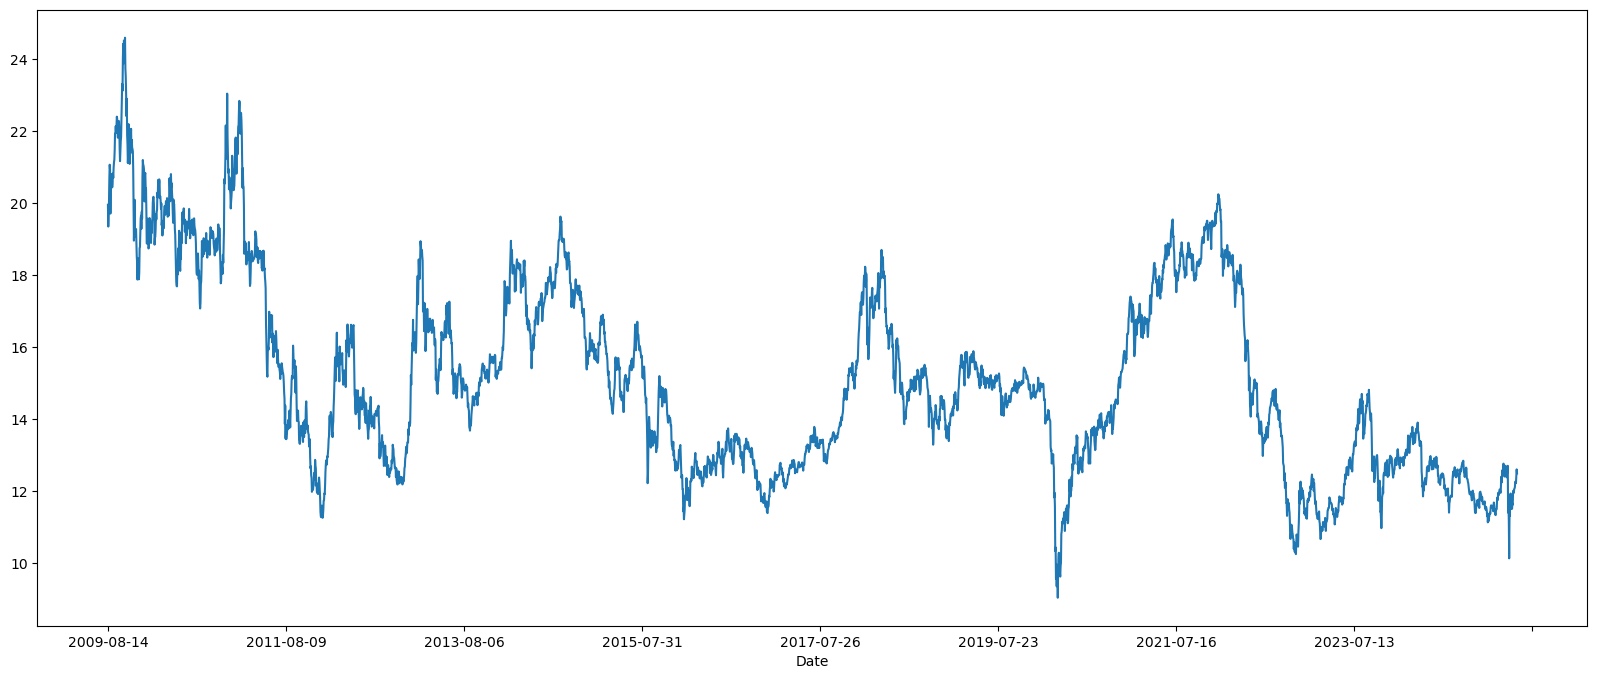

In [19]:
plt.rcParams['figure.figsize'] = (20, 8)
df['Close'].plot()

In [51]:
def getXy(data, window_size = 3):
    n = len(data) - window_size
    dic = {}
    for i in range(window_size):
        dic[f'X{i}'] = data[i : n + i]
    df = pd.DataFrame(data = dic)
    return df.values, data[window_size:]

In [52]:
window_size = 3
X, y = getXy(df['Close'].values, window_size)
X.shape, y.shape

((3956, 3), (3956,))

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [68]:
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.9896115959414344, 0.9947179977145)

In [69]:
y_train_predict = lg.predict(X_train)
y_test_predict = lg.predict(X_test)

In [70]:
df['PredictAutoRegression'] = np.concat(([np.nan] * window_size, y_train_predict, y_test_predict))
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Predict,PredictAutoRegression
Date,,,,,,,,,,
2009-08-14,20.685430,20.708432,19.673393,19.949404,0,0.0,0.0,0.0,NaN,NaN
2009-08-17,19.972403,22.594500,19.320714,19.343714,0,0.0,0.0,0.0,NaN,NaN
2009-08-18,20.693101,20.693101,19.566060,19.742399,0,0.0,0.0,0.0,NaN,NaN
2009-08-19,19.803731,20.118076,19.604390,20.033739,0,0.0,0.0,0.0,NaN,19.712869
2009-08-20,20.248414,20.953774,20.240747,20.677763,0,0.0,0.0,0.0,NaN,20.005739


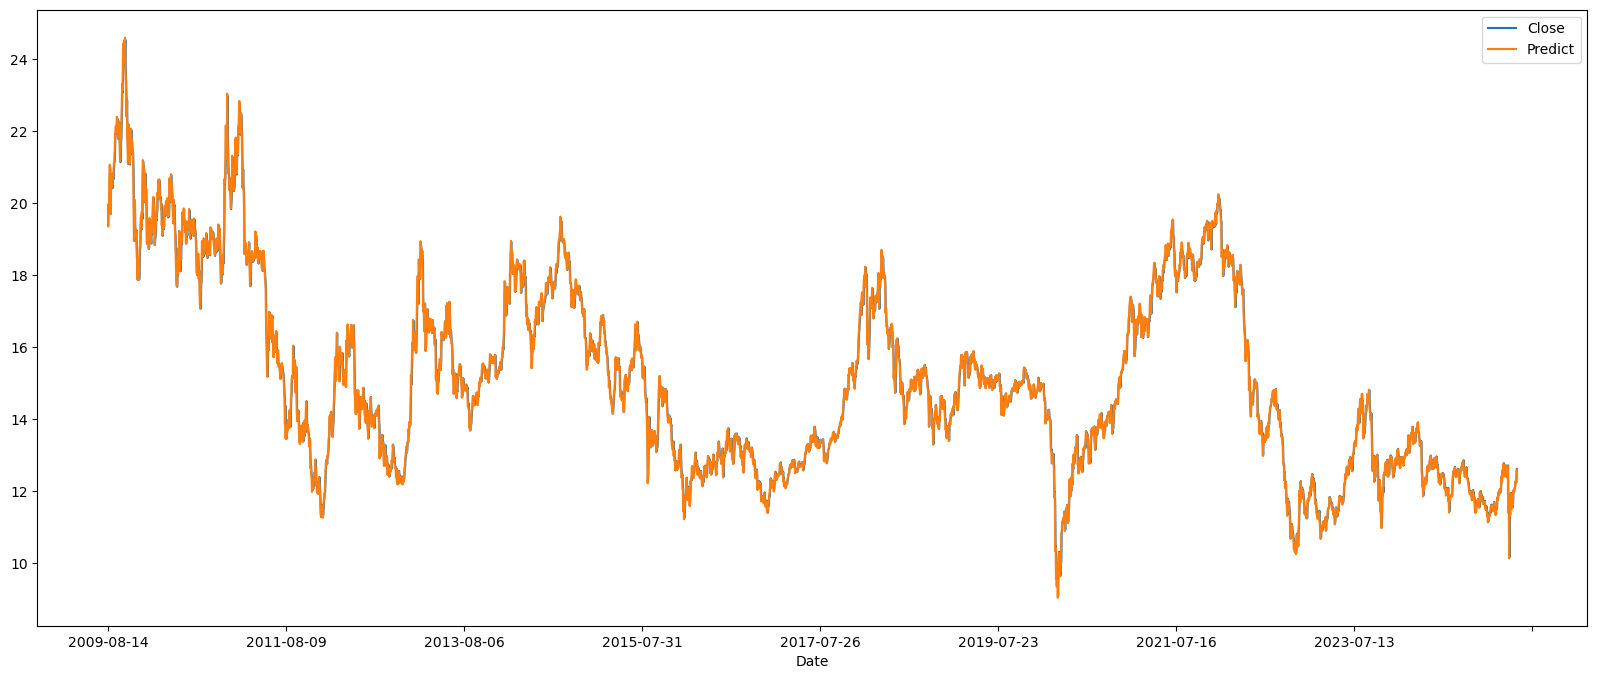

In [71]:

df['PredictAutoRegression'].plot()
df['Close'].plot()
plt.legend(['Close', 'Predict'])
plt.show()

In [73]:
X = df['Close'].values
X_train, X_test = train_test_split(X, shuffle=False)

In [35]:
X1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_test_split(X1, shuffle=False)

[[1, 2, 3, 4, 5, 6, 7], [8, 9, 10]]

In [ ]:
# 6. Fit ARIMA(p=1, d=2, q=1)
print("\nFit mô hình ARIMA(3,0,0)...")
model = sm.tsa.ARIMA(X_train, order=(3, 0, 0))
result = model.fit()

print("\nSummary của mô hình:")
print(result.summary())


Fit mô hình ARIMA(3,0,0)...

Summary của mô hình:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2969
Model:                 ARIMA(3, 0, 0)   Log Likelihood                -174.691
Date:                Sun, 11 May 2025   AIC                            359.382
Time:                        14:26:53   BIC                            389.362
Sample:                             0   HQIC                           370.172
                               - 2969                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.9531      0.911     17.512      0.000      14.168      17.739
ar.L1          0.9808      0.013     75.201      0.000       0.955       1.006
a

In [79]:
predict = result.forecast(steps=X_test.shape[0])
predict

array([18.41629931, 18.40476716, 18.39324098, 18.38176993, 18.37035271,
       18.35898916, 18.34767904, 18.33642208, 18.32521804, 18.31406668,
       18.30296773, 18.29192096, 18.28092611, 18.26998296, 18.25909124,
       18.24825073, 18.23746118, 18.22672235, 18.216034  , 18.2053959 ,
       18.19480781, 18.18426949, 18.17378071, 18.16334123, 18.15295084,
       18.14260928, 18.13231634, 18.12207179, 18.1118754 , 18.10172694,
       18.09162618, 18.08157291, 18.0715669 , 18.06160793, 18.05169577,
       18.04183021, 18.03201103, 18.02223801, 18.01251092, 18.00282957,
       17.99319372, 17.98360318, 17.97405772, 17.96455713, 17.9551012 ,
       17.94568972, 17.93632249, 17.92699929, 17.91771992, 17.90848417,
       17.89929184, 17.89014272, 17.8810366 , 17.8719733 , 17.8629526 ,
       17.85397431, 17.84503822, 17.83614415, 17.82729188, 17.81848123,
       17.80971199, 17.80098398, 17.792297  , 17.78365085, 17.77504535,
       17.7664803 , 17.75795552, 17.74947081, 17.74102599, 17.73

In [80]:
df['Predict'] = np.concat(([np.nan] * X_train.shape[0], predict))
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Predict,PredictAutoRegression
Date,,,,,,,,,,
2025-05-05,12.24,12.29,12.22,12.27,208300,0.0,0.0,0.0,15.976813,12.255465
2025-05-06,12.23,12.30,12.20,12.22,579200,0.0,0.0,0.0,15.976701,12.286758
2025-05-07,12.26,12.42,12.26,12.42,362400,0.0,0.0,0.0,15.976590,12.237898
2025-05-08,12.49,12.64,12.49,12.60,782400,0.0,0.0,0.0,15.976480,12.433433
2025-05-09,12.51,12.59,12.47,12.49,870000,0.0,0.0,0.0,15.976370,12.613148


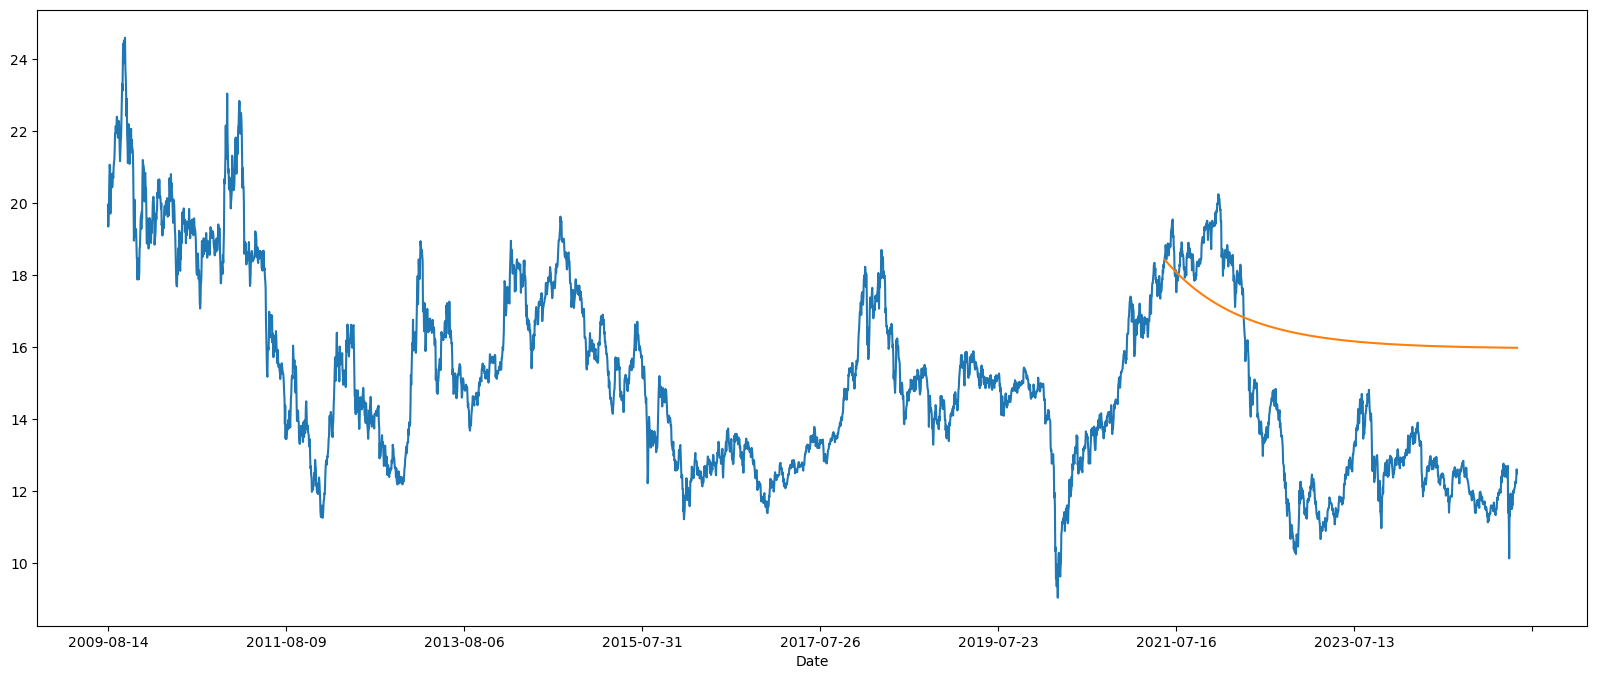

In [81]:
df['Close'].plot()
df['Predict'].plot()
plt.show()

In [ ]:
df_data = df[["Country Name", "Country Code", "Indicator Name", "1960", "1990", "2000", "2010", "2020"]].copy()
df_data.tail()



,Country Name,Country Code,Indicator Name,1960,1990,2000,2010,2020
261,Kosovo,XKX,Consumer price index (2010 = 100),NaN,NaN,NaN,100.0,118.299686
262,"Yemen, Rep.",YEM,Consumer price index (2010 = 100),NaN,3.844686,34.239173,100.0,NaN
263,South Africa,ZAF,Consumer price index (2010 = 100),1.775116,25.469449,59.990478,100.0,164.072367
264,Zambia,ZMB,Consumer price index (2010 = 100),NaN,0.216873,23.828288,100.0,245.711424
265,Zimbabwe,ZWE,Consumer price index (2010 = 100),NaN,NaN,NaN,100.0,2725.312815


In [3]:
# Lọc dữ liệu Việt Nam
vn = df[df['Country Name'] == 'Vietnam'].drop(columns=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'])

# Chuyển sang time series
vn = vn.T
vn.columns = ['CPI']
vn.index.name = 'Year'

# Bỏ NaN và chuyển kiểu dữ liệu
vn = vn.dropna().astype(float)

# ✅ Lọc từ 2010 trở đi
vn = vn.loc[vn.index.astype(int) >= 2010]

print(vn.head())

ValueError: Length mismatch: Expected axis has 0 elements, new values have 1 elements